# 08 — Multi-LLM side-car: three synthetic LLMs, one lattice join

The proposal from `docs/notes/multi-llm-sidecar-notes.md`: run the same
`ewm-state-machine` as a side-car against **m LLMs at once**, with the system
state as their lattice join:

```text
S(t) = S_1(t) ∪ S_2(t) ∪ … ∪ S_m(t)        S_i(t) = HLLSet state of the i-th LLM
```

The m-dimensional BSS similarity vector associates with S(t):

```text
bss(t) = [w_1(t), …, w_m(t)],   w_i(t) = |S(t) ∩ B_i| / |B_i|
```

where the basis B = (B_1, …, B_m) is the ring built over the per-LLM
HLLSets. The sequence `bss(1), bss(2), …` is the **system trajectory**.

One operator, three levels — the whole hierarchy is a training ground:

| Pattern | Leaves | System state | Decomposition |
| - | - | - | - |
| `(LLM, Ring)` | 3 synthetic LLMs | union of per-LLM HLLSets | m-dim BSS vector over the per-LLM ring |
| `(LLM, Ring, DRN)` | 3 synthetic LLMs | union stream | DRN of the union stream AND of each S_i(t) |
| `(Ring, Ring, DRN)` | rings instead of LLMs | union of per-ring states | DRN over ring states (recursion) |

All of it runs on the existing machinery — `ewm-scene pyramid`, `sidecar`,
`noether`, `project`, `materialize` — no Rust changes.

In [1]:
import json, os, subprocess
import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_SCENE_BIN = os.path.join(EWM_SM, "target/debug/ewm-scene")
WORK = "/home/alexmy/.cache/ewm-multi-llm"
os.makedirs(WORK, exist_ok=True)

if not os.path.exists(EWM_SCENE_BIN):
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"], cwd=EWM_SM, check=True)

def ewm_scene(*args):
    r = subprocess.run([EWM_SCENE_BIN, *args], capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-scene failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())

print("ewm-scene:", EWM_SCENE_BIN)
print("work:", WORK)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm


In [2]:
# ── Three synthetic LLM probes ─────────────────────────────────────────────
# Each probe is the only model-specific part: it emits a tid{n} token stream.
#   llm_a — chatty drift: stable core + a slowly sliding window
#   llm_b — bursty: stable base + novelty bursts every 10 steps
#   llm_c — cyclic: revisits one of three blocks, with an old-block echo
#   shared 1000..1023 — overlapping "context" all three models touch.
T = 64

def probe_a(t):
    core = [f"tid{i}" for i in range(0, 32)]
    drift = [f"tid{32 + ((t + k) % 96)}" for k in range(16)]
    shared = [f"tid{s}" for s in range(1000, 1008 + (t // 8) % 8)]
    return core + drift + shared

def probe_b(t):
    base = [f"tid{i}" for i in range(200, 232)]
    burst = []
    if t % 10 in (0, 1, 2):
        b = (t // 10) % 4
        burst = [f"tid{240 + b * 32 + k}" for k in range(24)]
    shared = [f"tid{s}" for s in range(1016, 1024 - (t // 6) % 8)]
    return base + burst + shared

def probe_c(t):
    block = (t // 16) % 3
    base = [f"tid{400 + block * 32 + k}" for k in range(28)]
    revisit = ([f"tid{400 + ((block + 2) % 3) * 32 + k}" for k in range(8)]
               if (t % 16) >= 8 else [])
    shared = [f"tid{s}" for s in range(1000, 1016)] if t % 12 < 6 else []
    return base + revisit + shared

probes = {"llm_a": probe_a, "llm_b": probe_b, "llm_c": probe_c}
names = list(probes)
steps = {n: [probes[n](t) for t in range(T)] for n in names}

# System-wide hold phases: every 12 steps the whole system freezes for four
# steps (no new bits) — the commit condition is exercised in both directions.
for t in range(T):
    if t % 12 in (6, 7, 8, 9):
        for n in names:
            steps[n][t] = list(steps[n][t - 1])

# Write the pyramid file (m perceptrons per frame) and per-LLM flat streams.
PYRAMID_JSONL = f"{WORK}/pyramid_frames.jsonl"
with open(PYRAMID_JSONL, "w") as fh:
    for t in range(T):
        fh.write(json.dumps({"id": t + 1, "perceptrons": {n: steps[n][t] for n in names}}) + "\n")

LLM_JSONL = {}
for n in names:
    p = f"{WORK}/{n}.jsonl"
    LLM_JSONL[n] = p
    with open(p, "w") as fh:
        for t in range(T):
            fh.write(json.dumps({"id": t + 1, "tokens": steps[n][t]}) + "\n")

union_tokens = [[tok for n in names for tok in steps[n][t]] for t in range(T)]
UNION_JSONL = f"{WORK}/union_frames.jsonl"
with open(UNION_JSONL, "w") as fh:
    for t, toks in enumerate(union_tokens, 1):
        fh.write(json.dumps({"id": t, "tokens": toks}) + "\n")

print("frames:", T, "| LLMs:", names)
print("token counts (t=0):", {n: len(steps[n][0]) for n in names})
print("hold steps:", [t + 1 for t in range(T) if t % 12 in (6, 7, 8, 9)][:12], "...")
print("wrote", PYRAMID_JSONL, "and per-LLM streams")

frames: 64 | LLMs: ['llm_a', 'llm_b', 'llm_c']
token counts (t=0): {'llm_a': 56, 'llm_b': 64, 'llm_c': 44}
hold steps: [7, 8, 9, 10, 19, 20, 21, 22, 31, 32, 33, 34] ...
wrote /home/alexmy/.cache/ewm-multi-llm/pyramid_frames.jsonl and per-LLM streams


## §1 — Scaffold: `ewm-scene pyramid` with m LLM probes per frame

The pyramid command ingests the m perceptrons, computes the per-LLM HLLSets
`S_i(t)` and the union top state `S(t)`. This is notebook 04's machinery with
the perceptrons replaced by LLM probes — the only model-specific code is the
three `probe_*` functions above.

In [3]:
pyr = ewm_scene("pyramid", PYRAMID_JSONL)
print("perceptrons:", pyr["names"])
print("frames:", len(pyr["frames"]))
print("union pops (first 12):", [f["union_pop"] for f in pyr["frames"][:12]])
print("frame 1 per-LLM pops:", {p["name"]: p["pop"] for p in pyr["frames"][0]["perceptrons"]})
print("frame 1 union key:", pyr["frames"][0]["union_key"])

# IICA check: the union reached by the pyramid join (OR of per-LLM HLLSets)
# and the flat ingest of the concatenated token list must be the same node.
uni = ewm_scene("ingest", UNION_JSONL)
same_union = all(uni["frames"][i]["key"] == pyr["frames"][i]["union_key"] for i in range(T))
print("union discovered twice, keys agree (64/64):", same_union)

perceptrons: ['llm_a', 'llm_b', 'llm_c']
frames: 64
union pops (first 12): [428, 428, 428, 365, 366, 367, 367, 367, 367, 367, 429, 429]
frame 1 per-LLM pops: {'llm_a': 162, 'llm_b': 189, 'llm_c': 128}
frame 1 union key: h:71b9796afe8e35e8d5f776a9733c9f22ac3ec5ef
union discovered twice, keys agree (64/64): True


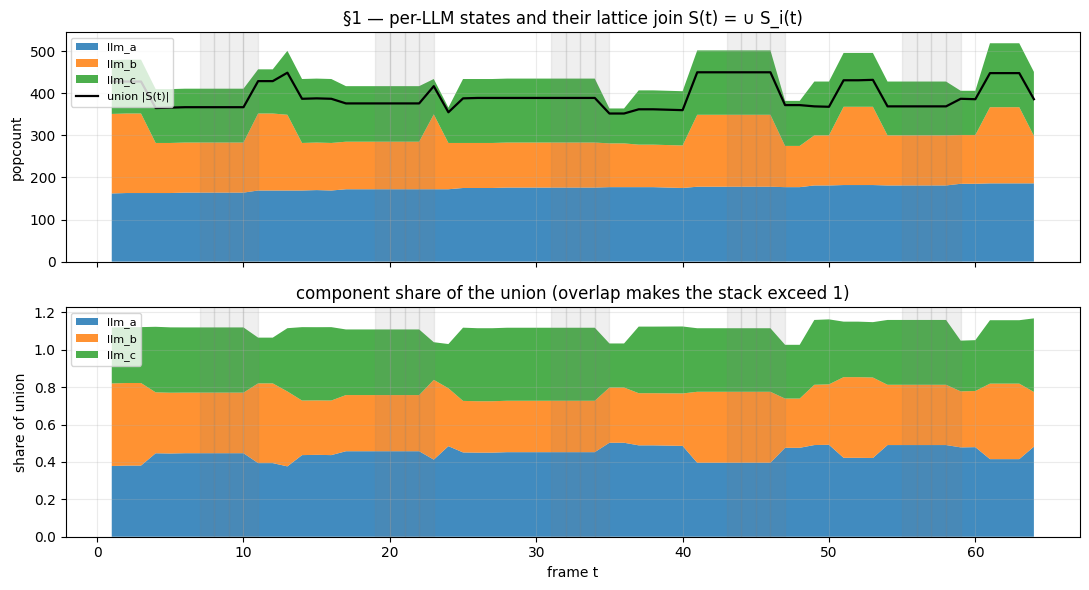

mean component share: {'llm_a': 0.446, 'llm_b': 0.331, 'llm_c': 0.337}
saved /home/alexmy/.cache/ewm-multi-llm/multi_llm_union.png


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

pops = np.array([[p["pop"] for p in f["perceptrons"]] for f in pyr["frames"]], dtype=float)
union_pops = np.array([f["union_pop"] for f in pyr["frames"]], dtype=float)
t_axis = np.arange(1, T + 1)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].stackplot(t_axis, pops.T, labels=pyr["names"], alpha=0.85)
axes[0].plot(t_axis, union_pops, color="black", lw=1.6, label="union |S(t)|")
axes[0].set_ylabel("popcount")
axes[0].set_title("§1 — per-LLM states and their lattice join S(t) = ∪ S_i(t)")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(alpha=0.25)

share = pops / union_pops[:, None]
axes[1].stackplot(t_axis, share.T, labels=pyr["names"], alpha=0.85)
axes[1].set_ylabel("share of union")
axes[1].set_xlabel("frame t")
axes[1].set_title("component share of the union (overlap makes the stack exceed 1)")
axes[1].legend(fontsize=8, loc="upper left")
axes[1].grid(alpha=0.25)

for t in range(T):
    if t % 12 in (6, 7, 8, 9):
        for ax in axes:
            ax.axvspan(t + 1, t + 2, color="gray", alpha=0.12)
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_union.png", dpi=110)
plt.show()

print("mean component share:", {n: round(float(share[:, i].mean()), 3) for i, n in enumerate(pyr["names"])})
print("saved", f"{WORK}/multi_llm_union.png")

## §2 — (LLM, Ring): per-LLM rings and the m-dim BSS trajectory

Each LLM stream is an HLLSet series, so `ewm-scene sidecar` builds its
Boolean-ring basis and records soft/hard keys, residual, dimension and
rotation. The **basis-change events** per LLM are the structural events of
that model's interpretation. Then `ewm-scene project` projects the union
stream onto the per-LLM cumulative HLLSets — the m-dim BSS vector per step.

In [5]:
sidecars = {n: ewm_scene("sidecar", LLM_JSONL[n]) for n in names}
for n in names:
    sc = sidecars[n]
    frames = sc["frames"]
    rot_events = sum(1 for f in frames if f["rotation_count"] > 0)
    rot_mass = sum(f["rotation_mass"] for f in frames)
    print(f"{n:6s} basis_generations={len(sc['basis_history']):2d}  "
          f"rotation_events={rot_events:2d}  total_rotation_mass={rot_mass:5d}  "
          f"final_dim={frames[-1]['dim']:2d}  jumps={sc['jumps']}")

llm_a  basis_generations=44  rotation_events=20  total_rotation_mass= 1083  final_dim=44  jumps=[47, 59]
llm_b  basis_generations=11  rotation_events= 8  total_rotation_mass=  296  final_dim=11  jumps=[49]
llm_c  basis_generations= 9  rotation_events= 6  total_rotation_mass=  178  final_dim= 9  jumps=[35, 49]


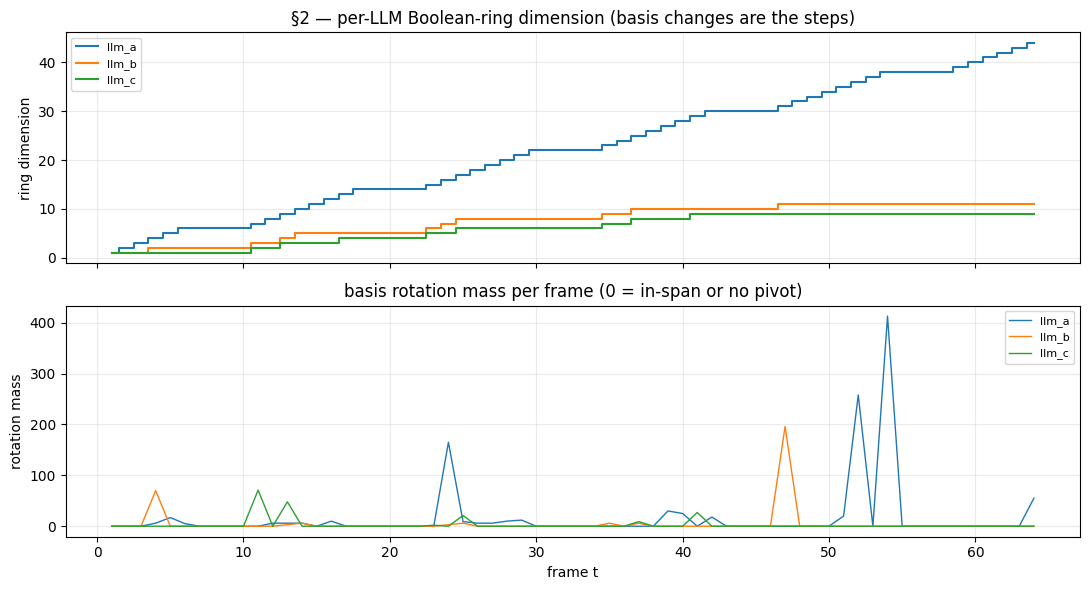

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for n in names:
    frames = sidecars[n]["frames"]
    dim = [f["dim"] for f in frames]
    axes[0].step(t_axis, dim, where="mid", label=n)
axes[0].set_ylabel("ring dimension")
axes[0].set_title("§2 — per-LLM Boolean-ring dimension (basis changes are the steps)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

for n in names:
    frames = sidecars[n]["frames"]
    rot = [f["rotation_mass"] for f in frames]
    axes[1].plot(t_axis, rot, label=n, lw=1.0)
axes[1].set_ylabel("rotation mass")
axes[1].set_xlabel("frame t")
axes[1].set_title("basis rotation mass per frame (0 = in-span or no pivot)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_rings.png", dpi=110)
plt.show()

In [7]:
# B = (B_1, B_2, B_3): the ring built over the per-LLM HLLSets. Here B_i is
# the cumulative HLLSet of LLM i over the whole clip (its vocabulary cover).
cum = {n: sorted({tok for t in range(T) for tok in steps[n][t]}) for n in names}
FRAME_LLMS = f"{WORK}/frame_llms.json"
with open(FRAME_LLMS, "w") as fh:
    json.dump({"dimensions": [{"name": n, "tokens": cum[n]} for n in names]}, fh)

proj = ewm_scene("project", UNION_JSONL, "--frame", FRAME_LLMS)
M = np.array([f["bss"] for f in proj["frames"]])
print("frame dims:", proj["names"], "pops:", proj["pops"])
print("BSS row (t=1):", [round(float(x), 3) for x in M[0]])
print("BSS row (t=64):", [round(float(x), 3) for x in M[-1]])

frame dims: ['llm_a', 'llm_b', 'llm_c'] pops: [354, 321, 283]
BSS row (t=1): [0.54, 0.62, 0.498]
BSS row (t=64): [0.554, 0.421, 0.558]


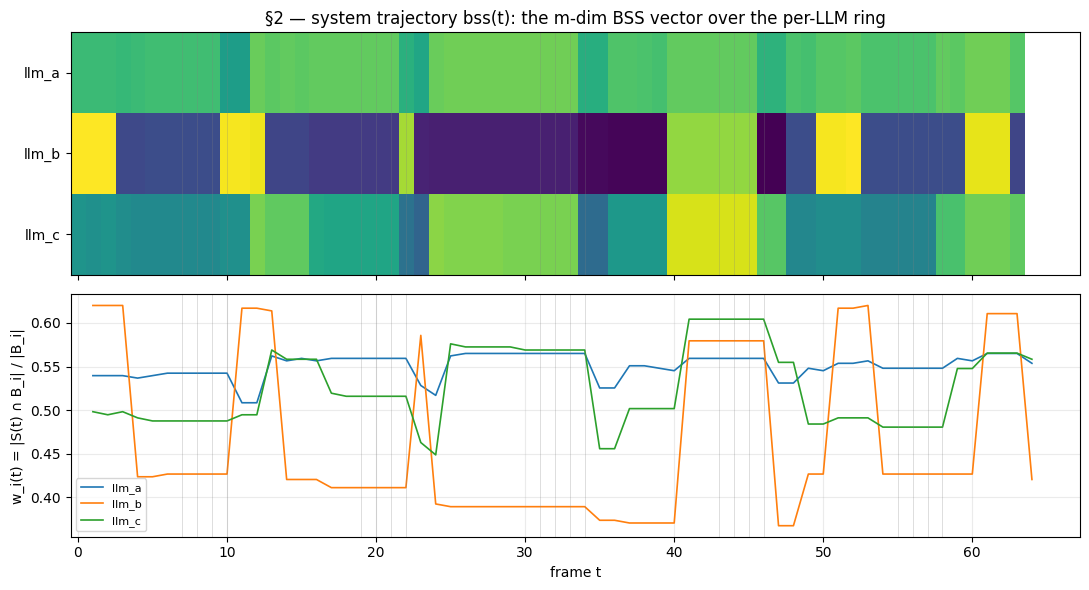

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].imshow(M.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_yticks(range(len(proj["names"])), proj["names"])
axes[0].set_title("§2 — system trajectory bss(t): the m-dim BSS vector over the per-LLM ring")
for n in names:
    i = proj["names"].index(n)
    axes[1].plot(t_axis, M[:, i], label=n, lw=1.2)
axes[1].set_ylabel("w_i(t) = |S(t) ∩ B_i| / |B_i|")
axes[1].set_xlabel("frame t")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)
for ax in axes:
    for t in range(T):
        if t % 12 in (6, 7, 8, 9):
            ax.axvline(t + 1, color="gray", alpha=0.3, lw=0.6)
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_bss.png", dpi=110)
plt.show()

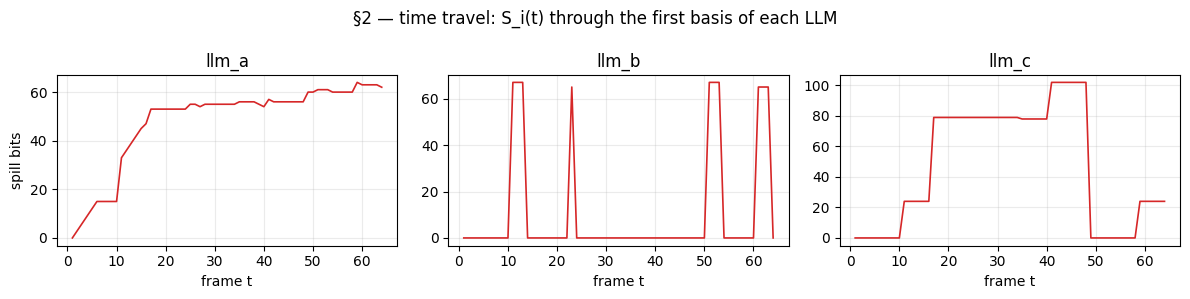

llm_a: final spill through the first basis = 62 bits
llm_b: final spill through the first basis = 0 bits
llm_c: final spill through the first basis = 24 bits


In [9]:
# Time travel (docs/BASIS_FRAMES.md): every per-LLM frame re-read through
# that LLM's FIRST basis. spill_first = |S_i(t) \ cover(F_0)| — the mass the
# initial interpretation cannot see.
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
for ax, n in zip(axes, names):
    sc = sidecars[n]
    spill = [f["spill_first"] for f in sc["frames"]]
    ax.plot(t_axis, spill, color="tab:red", lw=1.2)
    ax.set_title(n)
    ax.set_xlabel("frame t")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("spill bits")
fig.suptitle("§2 — time travel: S_i(t) through the first basis of each LLM")
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_timetravel.png", dpi=110)
plt.show()

for n in names:
    spill = [f["spill_first"] for f in sidecars[n]["frames"]]
    print(f"{n}: final spill through the first basis = {spill[-1]} bits")

## §3 — (LLM, Ring, DRN): DRN of the union stream and of every S_i(t)

The D/R/N decomposition is stream-agnostic: `ewm-scene noether` computes it
for each per-LLM HLLSet stream, and the pyramid already computed it for the
union. The Noether balance `|N| − |D|` per transition tells how much each
stream replaces.

In [10]:
noethers = {n: ewm_scene("noether", LLM_JSONL[n]) for n in names}
drn = pyr["drn"]  # system DRN of the union stream

def balance_table(name, dp, rp, np_):
    d = np.array(dp, dtype=float)
    r = np.array(rp, dtype=float)
    n = np.array(np_, dtype=float)
    return {
        "stream": name,
        "ΣD": int(d.sum()), "ΣR": int(r.sum()), "ΣN": int(n.sum()),
        "Σ(|N|-|D|)": int((n - d).sum()),
        "mean(|N|-|D|)": round(float((n - d).mean()), 2),
    }

rows = [balance_table("system S(t)", drn["dp"], drn["rp"], drn["np"])]
for n in names:
    no = noethers[n]
    rows.append(balance_table(n, no["dp"], no["rp"], no["np"]))
for r in rows:
    print(f"{r['stream']:12s} ΣD={r['ΣD']:5d}  ΣR={r['ΣR']:5d}  ΣN={r['ΣN']:5d}  "
          f"Σ(|N|-|D|)={r['Σ(|N|-|D|)']:5d}  mean={r['mean(|N|-|D|)']:6.2f}")

system S(t)  ΣD=  903  ΣR=23919  ΣN=  861  Σ(|N|-|D|)=  -42  mean= -0.67
llm_a        ΣD=  178  ΣR=10826  ΣN=  202  Σ(|N|-|D|)=   24  mean=  0.38
llm_b        ΣD=  437  ΣR= 7884  ΣN=  361  Σ(|N|-|D|)=  -76  mean= -1.21
llm_c        ΣD=  536  ΣR= 7802  ΣN=  560  Σ(|N|-|D|)=   24  mean=  0.38


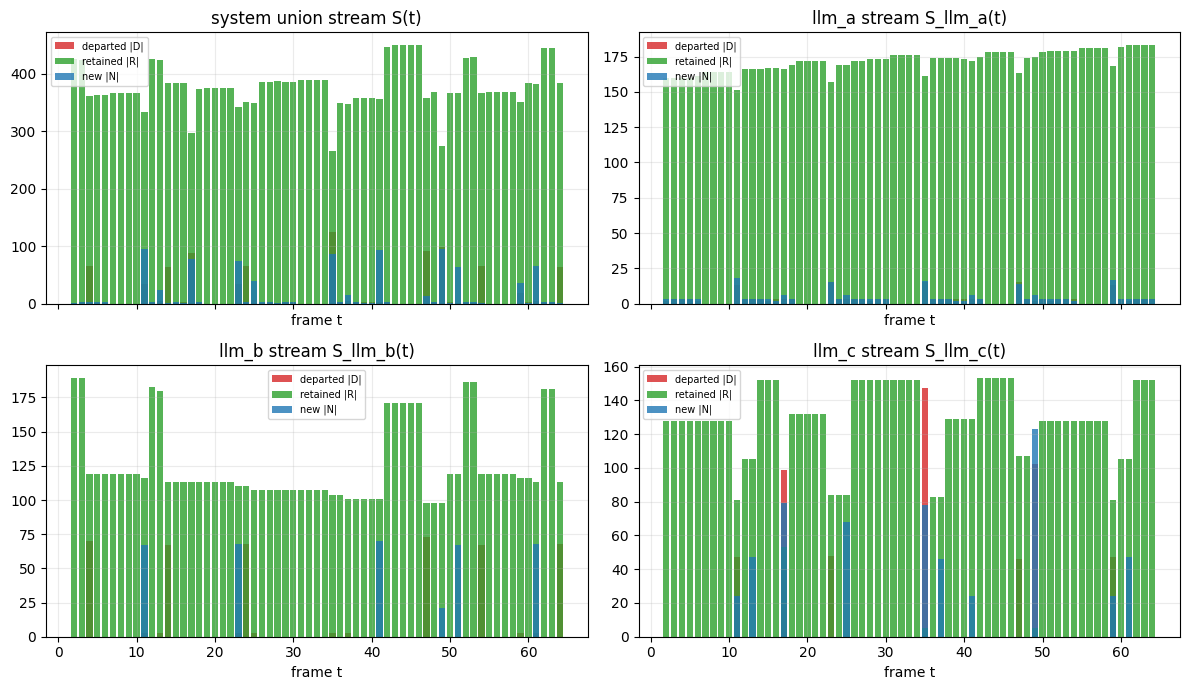

In [11]:
def plot_drn(ax, dp, rp, np_, title):
    dp = np.array(dp, dtype=float)
    rp = np.array(rp, dtype=float)
    np_ = np.array(np_, dtype=float)
    tt = np.arange(2, T + 1)
    ax.bar(tt, dp, color="#d62728", alpha=0.8, label="departed |D|")
    ax.bar(tt, rp, color="#2ca02c", alpha=0.8, label="retained |R|")
    ax.bar(tt, np_, color="#1f77b4", alpha=0.8, label="new |N|")
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
plot_drn(axes[0, 0], drn["dp"], drn["rp"], drn["np"], "system union stream S(t)")
for ax, n in zip(axes.flat[1:], names):
    no = noethers[n]
    plot_drn(ax, no["dp"], no["rp"], no["np"], f"{n} stream S_{n}(t)")
for ax in axes.flat:
    ax.set_xlabel("frame t")
plt.tight_layout()
plt.savefig(f"{WORK}/multi_llm_drn.png", dpi=110)
plt.show()

## §4 — (Ring, Ring, DRN): ring states as virtual LLMs (the recursion step)

A ring is just another HLLSet stream, so a ring can be a "virtual LLM".
`ewm-scene materialize` lowers each per-LLM HLLSet state back to a token set;
those sets become the leaves of a **second-level pyramid**. The recursion
must discover the same union node and the same DRN — the lattice is one
universe at every level.

In [12]:
mats = {n: ewm_scene("materialize", LLM_JSONL[n]) for n in names}

RING_PYRAMID_JSONL = f"{WORK}/ring_pyramid_frames.jsonl"
with open(RING_PYRAMID_JSONL, "w") as fh:
    for t in range(T):
        fh.write(json.dumps({"id": t + 1, "perceptrons": {
            f"ring_{n}": mats[n]["frames"][t]["set"] for n in names}}) + "\n")

pyr2 = ewm_scene("pyramid", RING_PYRAMID_JSONL)
print("level-2 perceptrons:", pyr2["names"])

# (1) The second-level union is the same lattice node as the first-level union.
same_union2 = all(pyr2["frames"][i]["union_key"] == pyr["frames"][i]["union_key"] for i in range(T))
print("level-2 union == level-1 union (keys agree):", same_union2)

# (2) The DRN over ring states is identical to the DRN over the original union.
same_drn = (pyr2["drn"]["dp"] == drn["dp"] and pyr2["drn"]["rp"] == drn["rp"]
            and pyr2["drn"]["np"] == drn["np"])
print("level-2 DRN == level-1 DRN:", same_drn)

# (3) Each ring leaf re-ingests to the same per-LLM HLLSet.
pops_ok = True
for t in range(T):
    for n in names:
        p1 = [p for p in pyr["frames"][t]["perceptrons"] if p["name"] == n][0]["pop"]
        p2 = [p for p in pyr2["frames"][t]["perceptrons"] if p["name"] == f"ring_{n}"][0]["pop"]
        pops_ok &= (p1 == p2)
print("ring-leaf pops == per-LLM pops (all frames):", pops_ok)

# (4) The second-level ring over the union stream matches the first-level ring.
ring_ok = all(pyr2["ring"]["frames"][i]["dim"] == pyr["ring"]["frames"][i]["dim"]
              and pyr2["ring"]["frames"][i]["residual"] == pyr["ring"]["frames"][i]["residual"]
              for i in range(T))
print("level-2 ring == level-1 ring (dim + residual):", ring_ok)

level-2 perceptrons: ['ring_llm_a', 'ring_llm_b', 'ring_llm_c']
level-2 union == level-1 union (keys agree): True
level-2 DRN == level-1 DRN: True
ring-leaf pops == per-LLM pops (all frames): True
level-2 ring == level-1 ring (dim + residual): True


## §5 — Training ground: the trajectory dataset and two first targets

The hierarchy produces a fixed-shape trajectory dataset:

| Field | Shape | Meaning |
| - | - | - |
| `bss(t)` | (T, m) | system trajectory in the per-LLM ring frame |
| `drn(t)` | (T−1, 3) | D/R/N popcounts of the union stream |
| `drn_i(t)` | (T−1, 3) | D/R/N popcounts of each LLM stream |
| `basis_change_i(t)` | (T,) | per-LLM basis-change events (rotation / dim) |

**Target 1 — next BSS vector.** Predict `bss(t+1)` from `bss(t)`. Baselines:
persistence (`bss(t)`) and linear extrapolation (`2·bss(t) − bss(t−1)`).

**Target 2 — next commit signal.** The commit condition is
`new bits > 0 or basis changed`. Label each transition `t → t+1` with the
ground-truth commit, and train a logistic probe on
`[bss(t), Δbss(t), sin(2πt/12), cos(2πt/12)]` — the ring's ingestion order is
the time axis, so phase features are part of the trajectory dataset.

In [13]:
# ── Target 1: next BSS vector ─────────────────────────────────────────────
persist_mse = np.mean([np.mean((M[t + 1] - M[t]) ** 2) for t in range(T - 1)])
lin_mse = np.mean([np.mean((M[t + 1] - (2 * M[t] - M[t - 1])) ** 2)
                   for t in range(1, T - 1)])
print("target 1 (next BSS vector):")
print(f"  persistence MSE      = {persist_mse:.6f}")
print(f"  linear extrapolation = {lin_mse:.6f}")
print("  -> persistence is the first baseline to beat on a 64-step clip")

# ── Target 2: next commit signal ──────────────────────────────────────────
# Ground truth: commit(t) = new bits > 0 OR the union basis changed.
commit = np.zeros(T - 1, dtype=int)
for t in range(T - 1):
    commit[t] = int(drn["np"][t] > 0
                    or pyr["ring"]["frames"][t + 1]["dim"] != pyr["ring"]["frames"][t]["dim"])

# Features known at time t: bss(t), Δbss(t), and the time phase.
def make_features(M):
    X = []
    for t in range(len(M) - 1):
        dM = M[t] - M[t - 1] if t > 0 else np.zeros(M.shape[1])
        row = (list(M[t]) + list(dM)
               + [float(np.sin(2 * np.pi * t / 12)), float(np.cos(2 * np.pi * t / 12))])
        X.append(row)
    return np.array(X, dtype=float)

X = make_features(M)
y = commit
cut = int(0.75 * len(X))
Xtr, Xte, ytr, yte = X[:cut], X[cut:], y[:cut], y[cut:]
mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0) + 1e-9
Xs, Xst = (Xtr - mu) / sd, (Xte - mu) / sd

# NumPy logistic regression (deterministic seed).
rng = np.random.default_rng(0)
w = rng.normal(0, 0.1, size=Xs.shape[1])
b = 0.0
for _ in range(5000):
    z = Xs @ w + b
    p = 1.0 / (1.0 + np.exp(-z))
    w -= 0.5 * (Xs.T @ (p - ytr)) / len(ytr)
    b -= 0.5 * np.mean(p - ytr)

def accuracy(Xs, y):
    p = 1.0 / (1.0 + np.exp(-(Xs @ w + b)))
    return np.mean((p >= 0.5).astype(int) == y)

print("\ntarget 2 (next commit signal):")
print(f"  commit rate      = {y.mean():.3f} ({int(y.sum())}/{len(y)} transitions)")
print(f"  logistic train   = {accuracy(Xs, ytr):.3f}")
print(f"  logistic test    = {accuracy(Xst, yte):.3f}")
print(f"  majority test    = {max(yte.mean(), 1 - yte.mean()):.3f}")
print("  -> the probe recovers the hold-phase commit schedule from the trajectory")

target 1 (next BSS vector):
  persistence MSE      = 0.002598
  linear extrapolation = 0.005469
  -> persistence is the first baseline to beat on a 64-step clip

target 2 (next commit signal):
  commit rate      = 0.683 (43/63 transitions)
  logistic train   = 1.000
  logistic test    = 1.000
  majority test    = 0.750
  -> the probe recovers the hold-phase commit schedule from the trajectory


## Summary

- **Scaffold** — three synthetic LLM probes feed `ewm-scene pyramid`; the
  union `S(t)` is the lattice join of the per-LLM HLLSets, and the union
  discovered by two independent paths has one content key (IICA, 64/64).
- **(LLM, Ring)** — each LLM's Boolean ring is a separate interpretation:
  `llm_a` drifts almost every step, `llm_b` re-indexes only at bursts, `llm_c`
  only at block switches. The m-dim BSS trajectory over the per-LLM ring is
  the system trajectory; time travel re-reads every `S_i(t)` through its first
  basis with an explicit spill.
- **(LLM, Ring, DRN)** — the Noether balance table gives each stream's
  replacement budget `Σ(|N|−|D|)`; the system row is the lattice-level
  balance over the union stream.
- **(Ring, Ring, DRN)** — materialized ring states as virtual LLMs reproduce
  the same union node, the same DRN and the same ring: the recursion step
  closes with no new machinery.
- **Training ground** — the trajectory dataset (BSS vectors, DRN balances,
  basis-change events) is now a fixed-shape table. Persistence is the first
  next-BSS baseline, and a logistic probe recovers the next-commit signal.

Next: real small models behind the same three `probe()` adapters, and a
sequence model (the system itself) trained on the trajectory dataset.